In [ ]:
!pip install entsoe-py

In [14]:
#Inputs for the dataset download
geographies = ["DE_LU", "ES", "FR"]
imb_mapping = {'ES': 'ES','FR': 'FR', 'DE_LU': 'DE'} #some geos need mapping of country to imbalance areas
technologies = ["B16"] #Solar
technology_mapping = {'B16': 'Sol','B18': 'OSW','B19': 'ONW',} # Technology mapping for cleaner column names

In [ ]:
from entsoe import EntsoePandasClient
import pandas as pd
from entsoe.exceptions import NoMatchingDataError

#Initialisation of data request, uses personal api key
client = EntsoePandasClient(api_key="YOURAPIKEY")
start = pd.Timestamp('20200101', tz='UTC') #start date of the downloaded set
end = pd.Timestamp('20251231', tz='UTC') #end date of the downloaded set

# 0.0.0 Create function to convert to quarter-hourly UTC timestamp
def make_hourly(df, ts_col="timestamp"):
  df = df.copy()
  df[ts_col] = pd.to_datetime(df[ts_col], utc=True)

  # Set timestamp as index
  df = df.set_index(ts_col).sort_index()

  # Keep only numeric columns
  numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
  df = df[numeric_cols]

  # Convert all data to quarter-hourly frequency and forward fill unknowns
  df = df.resample("15min").ffill()
  df.index.name = ts_col
  return df

# 0.0.1 Create function to add "timestamp" to first column and set as index, then adjust to hourly
def add_timestamp(df):
  df = df.reset_index()
  df = df.rename(columns={"index": "timestamp"})
  df = make_hourly(df)
  return df

# 0.0.2 Helper to remove consumption columns from generation pulls
def remove_consumption_columns(df):
  cols_to_keep = []

  for col in df.columns:
    # Convert MultiIndex tuple to a single string for checking
    col_str_for_check = ' '.join([str(x) for x in col]) if isinstance(col, tuple) else str(col)

    if 'Consumption' not in col_str_for_check:
      cols_to_keep.append(col)

  return df[cols_to_keep]


# 0.0.3 Converts the output of a generation / forecast pull into one column named:
  #{country_code}_{data_type}_{mapped_technology_name}

def standardise_generation_columns(df, country_code, data_type, tech, remove_consumption=False):

  #Removes Consumption column
  if remove_consumption:
    df = remove_consumption_columns(df)

  #Changes the column names to standardised version (easier for analysis)
  mapped_tech_name = technology_mapping.get(tech, tech)
  cleaned_tech_name = mapped_tech_name.replace(' ', '_')
  target_col_name = f"{country_code}_{data_type}_{cleaned_tech_name}"

  if not df.empty and not df.columns.empty:
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    if len(numeric_cols) > 0:
      aggregated_data = df[numeric_cols].sum(axis=1)
      df = pd.DataFrame({target_col_name: aggregated_data}, index=df.index)
    else:
      df = pd.DataFrame(columns=[target_col_name], index=df.index)
  else:
    df = pd.DataFrame(columns=[target_col_name], index=df.index)

  df.index.name = "timestamp"
  return df


# 0.1.0 - Day-ahead generation forecast
dfs_RES = []

def RES_forecast(country_code, startdate, enddate, tech):

  try:
    # Make the request
    df = client.query_wind_and_solar_forecast(country_code,start=startdate,end=enddate,psr_type=tech)
    df = add_timestamp(df)

    # Rename to {country_code}_DA_{mapped_tech_name}
    df = standardise_generation_columns(df=df,country_code=country_code,data_type="DA",tech=tech)
    dfs_RES.append(df)

  except NoMatchingDataError:
    print(f"No data found for {country_code}_DA_{technology_mapping.get(tech, tech)}")
    empty_df = pd.DataFrame()
    empty_df.index.name = "timestamp"
    dfs_RES.append(empty_df)

# 0.1.1 - Intraday generation forecast data pull
dfs_RES_ID = []

def RES_ID_forecast(country_code, startdate, enddate, tech):

  try:
    # Make the request
    df = client.query_intraday_wind_and_solar_forecast(country_code,start=startdate,end=enddate,psr_type=tech)
    df = add_timestamp(df)

    # Rename to {country_code}_ID_{mapped_tech_name}
    df = standardise_generation_columns(df=df,country_code=country_code,data_type="ID",tech=tech)
    dfs_RES_ID.append(df)

  except NoMatchingDataError:
    print(f"No data found for {country_code}_ID_{technology_mapping.get(tech, tech)}")
    empty_df = pd.DataFrame()
    empty_df.index.name = "timestamp"
    dfs_RES_ID.append(empty_df)

# 0.1.2 - Actual generation
dfs_RES_ACT = []

def RES_actual(country_code, startdate, enddate, tech):

  try:
    # Make the request
    df = client.query_generation(country_code,start=startdate,end=enddate,psr_type=tech)
    df = add_timestamp(df)

    # Rename to {country_code}_ACT_{mapped_tech_name}
    # Also remove "Consumption" outputs that come with actual generation pulls.
    df = standardise_generation_columns(df=df,country_code=country_code,data_type="ACT",tech=tech,
      remove_consumption=True)
    dfs_RES_ACT.append(df)

  except NoMatchingDataError:
    print(f"No data found for {country_code}_ACT_{technology_mapping.get(tech, tech)}")
    empty_df = pd.DataFrame()
    empty_df.index.name = "timestamp"
    dfs_RES_ACT.append(empty_df)

# 0.2.0 - Day-ahead and Imbalance prices
# Note: DA proxies ID here
dfs_prices = []

def price_data(country_code, startdate, enddate):

  # Day-Ahead price request
  try:
    df_da = client.query_day_ahead_prices(country_code,start=startdate,end=enddate)
    df_da = add_timestamp(df_da)
    df_da = df_da.rename(columns={0: f"{country_code}_DA_price"})
    dfs_prices.append(df_da)

  except NoMatchingDataError:
    print(f"No data found for {country_code}_DA_price")
    empty_df = pd.DataFrame()
    empty_df.index.name = "timestamp"
    dfs_prices.append(empty_df)

 # Imbalance price request, with a special bit of code because DE has a switch over in June 2022
  try:
    mapped_country_code = imb_mapping.get(country_code, country_code)
    de_imbalance_split_switch = 1
    imbalance_switch_date = pd.Timestamp("2022-06-21 00:00", tz=startdate.tz)

    if de_imbalance_split_switch == 1 and country_code == "DE_LU" and startdate < imbalance_switch_date and enddate > imbalance_switch_date:
      df_Imb_before = client.query_imbalance_prices(country_code, start=startdate, end=imbalance_switch_date)
      df_Imb_after = client.query_imbalance_prices(mapped_country_code, start=imbalance_switch_date, end=enddate)
      df_Imb = pd.concat([df_Imb_before, df_Imb_after])
      print(f"Imbalance data for {country_code} pulled using {country_code} until {imbalance_switch_date} and {mapped_country_code} after")

    elif de_imbalance_split_switch == 1 and country_code == "DE_LU" and enddate <= imbalance_switch_date:
      df_Imb = client.query_imbalance_prices(country_code, start=startdate, end=enddate)
      print(f"Imbalance data for {country_code} pulled using {country_code}")

    else:
      df_Imb = client.query_imbalance_prices(mapped_country_code, start=startdate, end=enddate)
      print(f"Imbalance data for {country_code} pulled using {mapped_country_code}")

    df_Imb = add_timestamp(df_Imb)
    df_Imb = df_Imb.rename(columns={"Long": f"{country_code}_Imb_long", "Short": f"{country_code}_Imb_short"})
    dfs_prices.append(df_Imb)

  except NoMatchingDataError:
    print(f"No data found for {country_code}_Imb_price")
    empty_df = pd.DataFrame()
    empty_df.index.name = "timestamp"
    dfs_prices.append(empty_df)

# 1.0.0 Fetch the data for all technologies and all countries
for countries in geographies:
  for tech in technologies:
    RES_forecast(countries, start, end, tech)
    RES_ID_forecast(countries, start, end, tech)
    RES_actual(countries, start, end, tech)

  price_data(countries, start, end)


# 1.0.1 Merge all dataframes along the timestamp column, and make timestamp index column
df = pd.concat(dfs_RES + dfs_RES_ID + dfs_RES_ACT + dfs_prices, axis=1)
df = df.reset_index()
print(df.head(24))

**Optional upload**

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

save_folder = "/content/drive/MyDrive/Colab Notebooks/Project - RES forecasts"
os.makedirs(save_folder, exist_ok=True)

csv_path = f"{save_folder}/entsoe_15min.csv"

df.to_csv(csv_path, index=False)

print(f"Saved CSV to: {csv_path}")

**Optional download**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

csv_path = "/content/drive/MyDrive/Colab Notebooks/Project - RES forecasts/entsoe_15min.csv"

df = pd.read_csv(csv_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print(df.head(24))

**Within set calculations**

In [18]:
# 2.0.0 Import numpy
import numpy as np

#2.0.1 Add columns for year, month, day and hour of timestamp
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
summary_rows = []

# 2.0.2 Compute forecast errors and forecast costs
for country_code in geographies:
  for tech in technologies:

    mapped_tech_name = technology_mapping.get(tech, tech)
    cleaned_tech_name = mapped_tech_name.replace(' ', '_')

    da_col = f"{country_code}_DA_{cleaned_tech_name}"
    id_col = f"{country_code}_ID_{cleaned_tech_name}"
    act_col = f"{country_code}_ACT_{cleaned_tech_name}"
    price_col = f"{country_code}_DA_price"
    long_price_col = f"{country_code}_Imb_long"
    short_price_col = f"{country_code}_Imb_short"

    id_error_col = f"{country_code}_ID_error_{cleaned_tech_name}"
    act_error_col = f"{country_code}_ACT_error_{cleaned_tech_name}"
    id_error_cost_col = f"{country_code}_ID_error_cost_{cleaned_tech_name}"
    act_error_cost_col = f"{country_code}_ACT_error_cost_{cleaned_tech_name}"
    da_revenue_col = f"{country_code}_DA_revenue_{cleaned_tech_name}"

    #This computes the error from DA to ID forecasts and computes the forecast cost
    #proxying the DA price for the missing ID price. Positive number is positive cash flow
    if da_col in df.columns and id_col in df.columns:
      df[id_error_col] = df[id_col] - df[da_col]
      df[id_error_cost_col] = df[id_error_col] * df[price_col] / 4
      df[da_revenue_col] = df[da_col] * df[price_col] / 4

    else:
      print(f"Missing columns for {id_error_col}")

    #Computes the error from ID forecast to actual generation and computes forecast cost
    #When the tech is short it pays Imbalance short and same with Long
    if id_col in df.columns and act_col in df.columns and long_price_col in df.columns and short_price_col in df.columns:
      df[act_error_col] = df[act_col] - df[id_col]
      df[act_error_cost_col] = np.where(
        df[act_error_col] >= 0,
        df[act_error_col] * df[long_price_col] / 4,
        df[act_error_col] * df[short_price_col] / 4)

    #Compute the live imbalance cost used for the tech in a given timestamp
    if act_col in df.columns and long_price_col in df.columns and short_price_col in df.columns:
      df[f"{country_code}_live_imbalance_cost_{cleaned_tech_name}"] = np.where(
        df[act_error_col] >= 0,
        df[long_price_col], df[short_price_col])

    #Calculations
    years = df['year'].unique()
    for year in years:
      year_df = df[df['year'] == year]
      total_da_revenue = year_df[da_revenue_col].sum() / 1_000_000
      total_id_error_cost = year_df[id_error_cost_col].sum() / 1_000_000
      total_act_error_cost = year_df[act_error_cost_col].sum() / 1_000_000
      total_gen = year_df[act_col].sum() / 4
      da_revenue_perMWh = total_da_revenue / total_gen * 1_000_000
      id_error_cost_perMWh = total_id_error_cost / total_gen * 1_000_000
      act_error_cost_perMWh = total_act_error_cost / total_gen * 1_000_000
      net_revenue_perMWh = da_revenue_perMWh + id_error_cost_perMWh + act_error_cost_perMWh
      #RMSE calculation for ID-> ACT
      rmse_threshold_mw = 100 #Avoids calculating RMSE when generation ultra-low
      rmse_df = year_df[
      (year_df[act_col].notna()) & (year_df[id_col].notna()) & (year_df[act_col] > rmse_threshold_mw)]

      if not rmse_df.empty:
        rmse = np.sqrt(((rmse_df[act_col] - rmse_df[id_col]) ** 2).mean())
      else:
        rmse = np.nan
      max_generation = year_df[act_col].max()

      if pd.notna(max_generation) and max_generation != 0:
        rmse_pct_of_max = rmse / max_generation * 100
      else:
       rmse_pct_of_max = np.nan

      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "generation_MWh",
                           "year": year,"value": total_gen})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "DA_revenue_EURm",
                           "year": year,"value": total_da_revenue})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "ID_error_cost_EURm",
                           "year": year,"value": total_id_error_cost})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "ACT_error_cost_EURm",
                           "year": year,"value": total_act_error_cost})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "da_revenue_perMWh",
                           "year": year,"value": da_revenue_perMWh})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "ID_error_cost_EUR_per_MWh",
                           "year": year,"value": id_error_cost_perMWh})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "ACT_error_cost_EUR_per_MWh",
                           "year": year,"value": act_error_cost_perMWh})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "net_revenue_EUR_per_MWh",
                           "year": year,"value": net_revenue_perMWh})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "RMSE_MW",
                           "year": year,"value": rmse})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "Max_generation",
                           "year": year,"value": max_generation})
      summary_rows.append({"country": country_code,"technology": cleaned_tech_name,"metric": "RMSE_pct_of_max_generation",
                           "year": year,"value": rmse_pct_of_max})

#2.0.3 Print the summary table
summary_df = pd.DataFrame(summary_rows)

summary_df["output_col"] = (
  summary_df["country"].astype(str) + "_" +
  summary_df["technology"].astype(str) + "_" +
  summary_df["year"].astype(str))

summary_table = summary_df.pivot_table(
  index="metric",
  columns="output_col",
  values="value",
  aggfunc="sum").reset_index()

summary_table.columns.name = None

metric_order = [
  "generation_MWh",
  "DA_revenue_EURm",
  "ID_error_cost_EURm",
  "ACT_error_cost_EURm",
  "da_revenue_perMWh",
  "ID_error_cost_EUR_per_MWh",
  "ACT_error_cost_EUR_per_MWh",
  "net_revenue_EUR_per_MWh", "RMSE_MW",
  "Max_generation", "RMSE_pct_of_max_generation"]

summary_table["metric"] = pd.Categorical(
  summary_table["metric"],
  categories=metric_order,
  ordered=True)

summary_table = summary_table.sort_values("metric").reset_index(drop=True)

#2.0.4 Nice formatted version below
summary_table_display = summary_table.copy()
value_cols = [col for col in summary_table_display.columns if col != "metric"]
for col in value_cols:
  summary_table_display[col] = summary_table_display.apply(
    lambda row: f"{row[col]:,.0f}" if row["metric"] == "generation_MWh"
    else f"{row[col]:.2f}",
    axis=1)
print(summary_table_display)


                        metric DE_LU_Sol_2020 DE_LU_Sol_2021 DE_LU_Sol_2022  \
0               generation_MWh     45,937,439     46,422,079     55,987,505   
1              DA_revenue_EURm        1134.68        3557.18       12491.70   
2           ID_error_cost_EURm           0.06         -16.99         -28.39   
3          ACT_error_cost_EURm         -92.47        -142.13        -184.56   
4            da_revenue_perMWh          24.70          76.63         223.12   
5    ID_error_cost_EUR_per_MWh           0.00          -0.37          -0.51   
6   ACT_error_cost_EUR_per_MWh          -2.01          -3.06          -3.30   
7      net_revenue_EUR_per_MWh          22.69          73.20         219.31   
8                      RMSE_MW         860.33         920.58        1027.94   
9               Max_generation       33347.54       36369.42       38108.09   
10  RMSE_pct_of_max_generation           2.58           2.53           2.70   

   DE_LU_Sol_2023 DE_LU_Sol_2024 DE_LU_Sol_2025 ES_

**Import IRENA LCOE data**

In [19]:
#Load IRENA solar LCOE data and convert from USD/MWh to EUR/MWh
import pandas as pd

lcoe_path = "/content/drive/MyDrive/Colab Notebooks/Project - RES forecasts/IRENA_lcoe.csv"
lcoe_df = pd.read_csv(lcoe_path)
lcoe_df.dropna(subset=['Year'], inplace=True)
lcoe_df["Year"] = lcoe_df["Year"].astype(int)

lcoe_country_cols = ["DE_LU", "ES", "FR"]

for col in lcoe_country_cols:
  lcoe_df[f"{col}_EUR_MWh"] = lcoe_df[col] * lcoe_df["FX USD->EUR"]

print(lcoe_df.head(7))

   Year   DE_LU      ES      FR  FX USD->EUR  DE_LU_EUR_MWh  ES_EUR_MWh  \
0  2020  61.319  50.299  60.750        0.877      53.776763   44.112223   
1  2021  58.096  53.668  55.964        0.846      49.149216   45.403128   
2  2022  72.880  47.738  64.313        0.950      69.236000   45.351100   
3  2023  51.802  39.491  53.715        0.925      47.916850   36.529175   
4  2024  59.338  53.061  71.245        0.924      54.828312   49.028364   
5  2025  59.338  53.061  71.245        0.886      52.573468   47.012046   

   FR_EUR_MWh  
0   53.277750  
1   47.345544  
2   61.097350  
3   49.686375  
4   65.830380  
5   63.123070  


**This is where the fun begins** - Imbalance adjustment algorithm

In [23]:
# 3.0.0 Simulate ID to ACT imbalance errors using month-hour RMSE buckets
import numpy as np
import pandas as pd

# This creates a function to simulate asset-level imbalance errors using month-hour fleet RMSE buckets
def simulate_id_to_act_imbalance_errors(df, country_code, tech, year, N=100, rho=0.5, n_sims=100, rmse_threshold_mw=50, random_seed=42):
  np.random.seed(random_seed)
  mapped_tech_name = technology_mapping.get(tech, tech)
  cleaned_tech_name = mapped_tech_name.replace(' ', '_')
  id_col = f"{country_code}_ID_{cleaned_tech_name}"
  act_col = f"{country_code}_ACT_{cleaned_tech_name}"
  long_price_col = f"{country_code}_Imb_long"
  short_price_col = f"{country_code}_Imb_short"
  act_error_cost_col = f"{country_code}_ACT_error_cost_{cleaned_tech_name}"
  required_cols = [id_col, act_col, long_price_col, short_price_col, act_error_cost_col]
  missing_cols = [col for col in required_cols if col not in df.columns]
  if missing_cols:
    print(f"Missing columns for {country_code}, {cleaned_tech_name}, {year}: {missing_cols}")
    return pd.DataFrame()

  work_df = df[df["year"] == year].copy()
  if "month" not in work_df.columns:
    work_df["month"] = work_df["timestamp"].dt.month
  if "hour" not in work_df.columns:
    work_df["hour"] = work_df["timestamp"].dt.hour

  year_df = work_df[required_cols + ["month", "hour"]].dropna().copy()
  if year_df.empty:
    print(f"No data for {country_code}, {cleaned_tech_name}, {year}")
    return pd.DataFrame()

  year_df["observed_fleet_error_MW"] = year_df[act_col] - year_df[id_col]
  rmse_mask = year_df[act_col].values > rmse_threshold_mw
  if rmse_mask.sum() == 0:
    print(f"No RMSE data above threshold for {country_code}, {cleaned_tech_name}, {year}")
    return pd.DataFrame()

  observed_rmse = np.sqrt(np.mean(year_df.loc[rmse_mask, "observed_fleet_error_MW"] ** 2))
  year_df["bucket_fleet_RMSE_MW"] = year_df.groupby(["month", "hour"])["observed_fleet_error_MW"].transform(lambda x: np.sqrt(np.mean(x ** 2)))
  year_df["bucket_asset_RMSE_MW"] = year_df["bucket_fleet_RMSE_MW"] / np.sqrt(N * (1 + (N - 1) * rho))

  T = len(year_df)
  fleet_size_MW = year_df[id_col].max()
  asset_size_MW = fleet_size_MW / N
  asset_id_forecast = year_df[id_col].values[:, None] / N
  bucket_asset_rmse = year_df["bucket_asset_RMSE_MW"].values[:, None]
  actual_fleet_cashflow_EUR = year_df[act_error_cost_col].sum()
  actual_fleet_generation_MWh = year_df[act_col].sum() / 4
  actual_fleet_cashflow_EUR_per_MWh = actual_fleet_cashflow_EUR / actual_fleet_generation_MWh
  actual_fleet_cashflow_EURm = actual_fleet_cashflow_EUR / 1_000_000
  results = []

  for sim in range(n_sims):
    observed_fleet_error = year_df[act_col].values - year_df[id_col].values
    base_asset_error = observed_fleet_error[:, None] / N
    Z_idio = np.random.normal(size=(T, N))
    Z_idio = Z_idio - Z_idio.mean(axis=1)[:, None]
    asset_errors = base_asset_error + Z_idio * bucket_asset_rmse
    asset_actual = asset_id_forecast + asset_errors
    #asset_actual = np.clip(asset_actual, 0, asset_size_MW)
    final_asset_errors = asset_actual - asset_id_forecast
    final_fleet_error = final_asset_errors.sum(axis=1)
    simulated_rmse = np.sqrt(np.mean(final_fleet_error[rmse_mask] ** 2))

    asset_imbalance_prices = np.where(final_asset_errors >= 0, year_df[long_price_col].values[:, None], year_df[short_price_col].values[:, None])
    asset_cashflows = final_asset_errors * asset_imbalance_prices / 4
    asset_generation_MWh = asset_actual.sum(axis=0) / 4
    asset_cashflow_EUR = asset_cashflows.sum(axis=0)
    asset_cashflow_EUR_per_MWh = np.where(asset_generation_MWh != 0, asset_cashflow_EUR / asset_generation_MWh, np.nan)
    avg_asset_cashflow_EUR_per_MWh = np.nanmean(asset_cashflow_EUR_per_MWh)

    asset_rmse_MW = np.sqrt(np.mean(final_asset_errors[rmse_mask, :] ** 2, axis=0))
    avg_asset_rmse_MW = np.nanmean(asset_rmse_MW)
    asset_rmse_pct = avg_asset_rmse_MW / asset_size_MW * 100
    fleet_rmse_pct = observed_rmse / fleet_size_MW * 100
    simulated_fleet_rmse_pct = simulated_rmse / fleet_size_MW * 100
    asset_minus_actual_fleet_EUR_per_MWh = avg_asset_cashflow_EUR_per_MWh - actual_fleet_cashflow_EUR_per_MWh

    results.append({"country": country_code, "technology": cleaned_tech_name, "year": year, "sim": sim, "rho": rho, "N": N, "Fleet_size_MW": fleet_size_MW, "Asset_size_MW": asset_size_MW, "observed_ID_to_ACT_RMSE_MW": observed_rmse, "simulated_fleet_ID_to_ACT_RMSE_MW": simulated_rmse, "avg_asset_ID_to_ACT_RMSE_MW": avg_asset_rmse_MW, "fleet_RMSE_pct": fleet_rmse_pct, "simulated_fleet_RMSE_pct": simulated_fleet_rmse_pct, "asset_RMSE_pct": asset_rmse_pct, "actual_fleet_ID_to_ACT_cashflow_EURm": actual_fleet_cashflow_EURm, "actual_fleet_ID_to_ACT_cashflow_EUR_per_MWh": actual_fleet_cashflow_EUR_per_MWh, "avg_asset_ID_to_ACT_cashflow_EUR_per_MWh": avg_asset_cashflow_EUR_per_MWh, "asset_minus_actual_fleet_ID_to_ACT_cashflow_EUR_per_MWh": asset_minus_actual_fleet_EUR_per_MWh})

  return pd.DataFrame(results)

# 3.0.1 Run ID to ACT imbalance simulations across several N and rho cases
switch = 0
N_cases = [1000]
rho_cases = [0.1, 0.5, 0.9]
sim_outputs = []

if switch == 1:
  for N in N_cases:
    for rho in rho_cases:
      sim_result = simulate_id_to_act_imbalance_errors(df, "DE_LU", "B16", 2025, N=N, rho=rho, n_sims=8, rmse_threshold_mw=50, random_seed=42)
      sim_outputs.append(sim_result)

  sim_results_df = pd.concat(sim_outputs, ignore_index=True)
  sim_summary_df = sim_results_df.groupby(["country", "technology", "year", "rho", "N", "Fleet_size_MW", "Asset_size_MW"], as_index=False).mean(numeric_only=True)
  sim_summary_df = sim_summary_df.drop(columns=["sim"], errors="ignore")
  print(sim_summary_df.head(50))

# 3.1.0 Add adjusted asset-level imbalance metrics to Section 2 summary table
asset_adjustment_N = 1000
asset_adjustment_rho = 0.75
asset_adjustment_n_sims = 5
asset_adjustment_rmse_threshold_mw = 50
adjusted_rows = []

for country_code in geographies:
  for tech in technologies:
    mapped_tech_name = technology_mapping.get(tech, tech)
    cleaned_tech_name = mapped_tech_name.replace(' ', '_')
    for year in sorted(df["year"].unique()):
      summary_col = f"{country_code}_{cleaned_tech_name}_{year}"
      if summary_col not in summary_table.columns:
        print(f"Missing summary column: {summary_col}")
        continue
      sim_result = simulate_id_to_act_imbalance_errors(df, country_code, tech, year, N=asset_adjustment_N, rho=asset_adjustment_rho, n_sims=asset_adjustment_n_sims, rmse_threshold_mw=asset_adjustment_rmse_threshold_mw, random_seed=42)
      if sim_result.empty:
        print(f"No simulation result for {country_code}, {cleaned_tech_name}, {year}")
        continue
      adjusted_imbalance_cost_perMWh = sim_result["avg_asset_ID_to_ACT_cashflow_EUR_per_MWh"].mean()
      adjusted_asset_rmse_pct = sim_result["asset_RMSE_pct"].mean()
      da_revenue_perMWh = summary_table.loc[summary_table["metric"] == "da_revenue_perMWh", summary_col].values[0]
      id_error_cost_perMWh = summary_table.loc[summary_table["metric"] == "ID_error_cost_EUR_per_MWh", summary_col].values[0]
      adjusted_net_revenue_perMWh = da_revenue_perMWh + id_error_cost_perMWh + adjusted_imbalance_cost_perMWh
      adjusted_rows.append({"country": country_code, "technology": cleaned_tech_name, "metric": "adjusted_ACT_error_cost_EUR_per_MWh", "year": year, "value": adjusted_imbalance_cost_perMWh})
      adjusted_rows.append({"country": country_code, "technology": cleaned_tech_name, "metric": "adjusted_asset_RMSE_pct", "year": year, "value": adjusted_asset_rmse_pct})
      adjusted_rows.append({"country": country_code, "technology": cleaned_tech_name, "metric": "adjusted_net_revenue_EUR_per_MWh", "year": year, "value": adjusted_net_revenue_perMWh})

# 3.1.1 Append adjusted rows and rebuild summary table
adjusted_summary_df = pd.DataFrame(adjusted_rows)
summary_df = summary_df[~summary_df["metric"].isin(["adjusted_ACT_error_cost_EUR_per_MWh", "adjusted_asset_RMSE_pct", "adjusted_net_revenue_EUR_per_MWh"])].copy()
summary_df = pd.concat([summary_df, adjusted_summary_df], ignore_index=True)
summary_df["output_col"] = summary_df["country"].astype(str) + "_" + summary_df["technology"].astype(str) + "_" + summary_df["year"].astype(str)

summary_table = summary_df.pivot_table(index="metric", columns="output_col", values="value", aggfunc="sum").reset_index()
summary_table.columns.name = None

metric_order = ["generation_MWh", "DA_revenue_EURm", "ID_error_cost_EURm", "ACT_error_cost_EURm", "da_revenue_perMWh", "ID_error_cost_EUR_per_MWh", "ACT_error_cost_EUR_per_MWh", "net_revenue_EUR_per_MWh", "RMSE_MW", "Max_generation", "RMSE_pct_of_max_generation", "adjusted_ACT_error_cost_EUR_per_MWh", "adjusted_asset_RMSE_pct", "adjusted_net_revenue_EUR_per_MWh"]
summary_table["metric"] = pd.Categorical(summary_table["metric"], categories=metric_order, ordered=True)
summary_table = summary_table.sort_values("metric").reset_index(drop=True)

summary_table_display = summary_table.copy()
value_cols = [col for col in summary_table_display.columns if col != "metric"]

for col in value_cols:
  summary_table_display[col] = summary_table_display.apply(lambda row: f"{row[col]:,.0f}" if row["metric"] in ["generation_MWh", "Max_generation"] else f"{row[col]:.2f}", axis=1)

print(summary_table_display)
csv_path = "/content/drive/MyDrive/Colab Notebooks/Project - RES forecasts/summary_table.csv"
summary_table.to_csv(csv_path, index=False)
print(f"Saved CSV file to: {csv_path}")



                                 metric DE_LU_Sol_2020 DE_LU_Sol_2021  \
0                        generation_MWh     45,937,439     46,422,079   
1                       DA_revenue_EURm        1134.68        3557.18   
2                    ID_error_cost_EURm           0.06         -16.99   
3                   ACT_error_cost_EURm         -92.47        -142.13   
4                     da_revenue_perMWh          24.70          76.63   
5             ID_error_cost_EUR_per_MWh           0.00          -0.37   
6            ACT_error_cost_EUR_per_MWh          -2.01          -3.06   
7               net_revenue_EUR_per_MWh          22.69          73.20   
8                               RMSE_MW         860.33         920.58   
9                        Max_generation         33,348         36,369   
10           RMSE_pct_of_max_generation           2.58           2.53   
11  adjusted_ACT_error_cost_EUR_per_MWh          -2.01          -3.06   
12              adjusted_asset_RMSE_pct           3

**Charts**

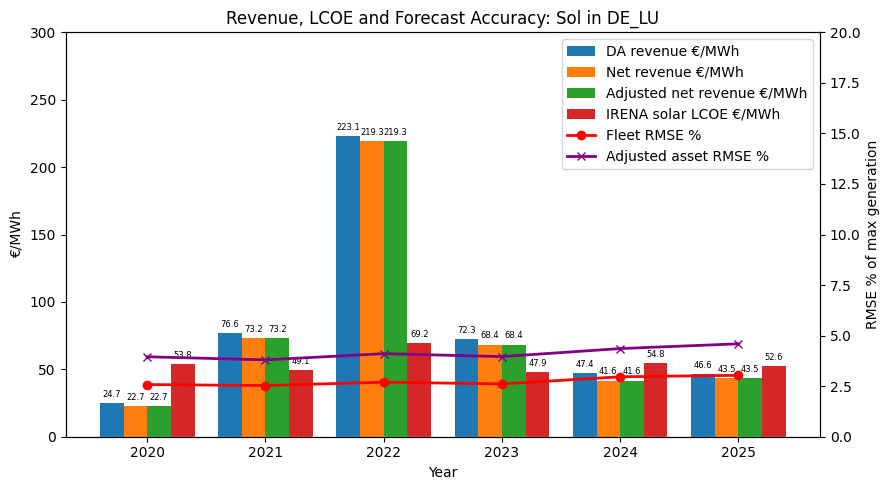

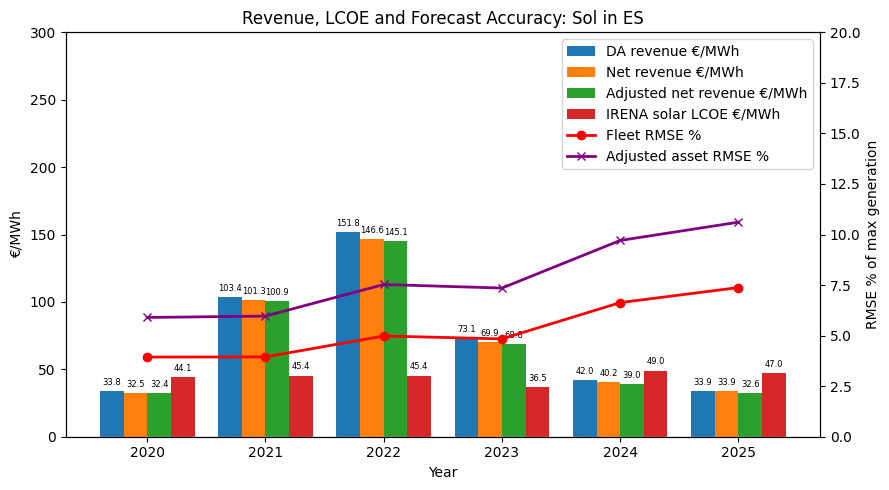

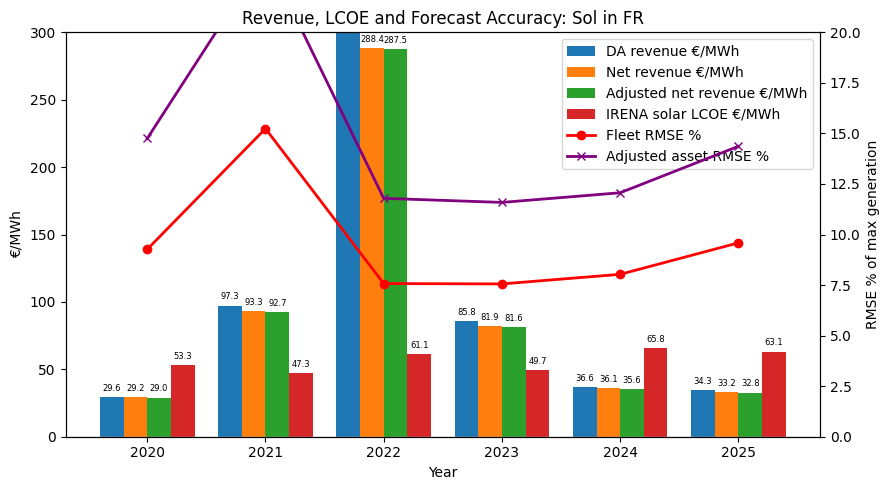

In [21]:
#Create plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for country_code in geographies:
  for tech in technologies:
    mapped_tech_name = technology_mapping.get(tech, tech)
    cleaned_tech_name = mapped_tech_name.replace(' ', '_')
    years = sorted(df['year'].unique())
    chart_rows = []

    for year in years:
      summary_col = f"{country_code}_{cleaned_tech_name}_{year}"
      lcoe_col = f"{country_code}_EUR_MWh"
      if summary_col not in summary_table.columns:
        print(f"Missing summary column: {summary_col}")
        continue
      if lcoe_col not in lcoe_df.columns:
        print(f"Missing LCOE column: {lcoe_col}")
        continue
      lcoe_match = lcoe_df.loc[lcoe_df["Year"] == int(year), lcoe_col]
      if lcoe_match.empty:
        print(f"Missing LCOE value for {country_code}, {year}")
        continue
      da_revenue_perMWh = summary_table.loc[summary_table["metric"] == "da_revenue_perMWh", summary_col].values[0]
      net_revenue_perMWh = summary_table.loc[summary_table["metric"] == "net_revenue_EUR_per_MWh", summary_col].values[0]
      adjusted_net_revenue_perMWh = summary_table.loc[summary_table["metric"] == "adjusted_net_revenue_EUR_per_MWh", summary_col].values[0]
      rmse_pct = summary_table.loc[summary_table["metric"] == "RMSE_pct_of_max_generation", summary_col].values[0]
      adjusted_asset_rmse_pct = summary_table.loc[summary_table["metric"] == "adjusted_asset_RMSE_pct", summary_col].values[0]
      lcoe_eur_per_mwh = lcoe_match.values[0]
      chart_rows.append({"year": int(year), "DA_revenue_perMWh": da_revenue_perMWh, "net_revenue_perMWh": net_revenue_perMWh, "adjusted_net_revenue_perMWh": adjusted_net_revenue_perMWh, "RMSE_pct": rmse_pct, "adjusted_asset_RMSE_pct": adjusted_asset_rmse_pct, "LCOE_EUR_per_MWh": lcoe_eur_per_mwh})

    chart_df = pd.DataFrame(chart_rows)
    if chart_df.empty:
      print(f"No bar chart data for {country_code}, {cleaned_tech_name}")
      continue

    x = np.arange(len(chart_df["year"]))
    width = 0.20
    fig, ax1 = plt.subplots(figsize=(9, 5))
    bars_da = ax1.bar(x - 1.5 * width, chart_df["DA_revenue_perMWh"], width, label="DA revenue €/MWh")
    bars_net = ax1.bar(x - 0.5 * width, chart_df["net_revenue_perMWh"], width, label="Net revenue €/MWh")
    bars_adj_net = ax1.bar(x + 0.5 * width, chart_df["adjusted_net_revenue_perMWh"], width, label="Adjusted net revenue €/MWh")
    bars_lcoe = ax1.bar(x + 1.5 * width, chart_df["LCOE_EUR_per_MWh"], width, label="IRENA solar LCOE €/MWh")
    ax1.bar_label(bars_da, fmt="%.1f", padding=3, fontsize=6)
    ax1.bar_label(bars_net, fmt="%.1f", padding=3, fontsize=6)
    ax1.bar_label(bars_adj_net, fmt="%.1f", padding=3, fontsize=6)
    ax1.bar_label(bars_lcoe, fmt="%.1f", padding=3, fontsize=6)
    ax1.set_xlabel("Year")
    ax1.set_ylabel("€/MWh")
    ax1.set_ylim(0, 300)
    ax1.set_xticks(x)
    ax1.set_xticklabels(chart_df["year"])
    ax1.axhline(0, color="lightgrey", linewidth=1)

    ax2 = ax1.twinx()
    ax2.plot(x, chart_df["RMSE_pct"], marker="o", linewidth=2, color="red", label="Fleet RMSE %")
    ax2.plot(x, chart_df["adjusted_asset_RMSE_pct"], marker="x", linewidth=2, color="purple", label="Adjusted asset RMSE %")
    ax2.set_ylabel("RMSE % of max generation")
    ax2.set_ylim(0, 20)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

    plt.title(f"Revenue, LCOE and Forecast Accuracy: {cleaned_tech_name} in {country_code}")
    plt.tight_layout()
    plt.show()

